# **Impact of Treatment Variables on Cancer Survival Prediction**

### Import Libraries

In [29]:
# !pip install eda_toolkit
# !pip install imbalanced-learn
from eda_toolkit import flex_corr_matrix
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import math
from matplotlib import gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_ind, chi2_contingency
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

### Load Dataset

In [5]:
#Read the dataset directly form the link
url = "https://www.cancerimagingarchive.net/wp-content/uploads/RADCURE_Clinical_v04_20241219.xlsx"
df = pd.read_excel(url)
df.head()

,patient_id,Age,Sex,ECOG PS,Smoking PY,Smoking Status,Ds Site,Subsite,T,N,...,Local,Date Local,Regional,Date Regional,Distant,Date Distant,2nd Ca,Date 2nd Ca,RADCURE-challenge,ContrastEnhanced
0,RADCURE-0005,62.6,Female,ECOG 0,50,Ex-smoker,Oropharynx,post wall,T4b,N2c,...,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0
1,RADCURE-0006,87.3,Male,ECOG 2,25,Ex-smoker,Larynx,Glottis,T1b,N0,...,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1
2,RADCURE-0007,49.9,Male,ECOG 1,15,Ex-smoker,Oropharynx,Tonsil,T3,N2b,...,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,1
3,RADCURE-0009,72.3,Male,ECOG 1,30,Ex-smoker,Unknown,NaN,T0,N2c,...,NaN,NaT,NaN,NaT,NaN,NaT,S (suspicious),2008-05-27,0,0
4,RADCURE-0010,59.7,Female,ECOG 0,0,Non-smoker,Oropharynx,Tonsillar Fossa,T4b,N0,...,NaN,NaT,NaN,NaT,NaN,NaT,NaN,NaT,0,0


In [6]:
#dtect nulls and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3346 entries, 0 to 3345
Data columns (total 34 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   patient_id         3346 non-null   object        
 1   Age                3346 non-null   float64       
 2   Sex                3346 non-null   object        
 3   ECOG PS            3345 non-null   object        
 4   Smoking PY         3341 non-null   object        
 5   Smoking Status     3346 non-null   object        
 6   Ds Site            3346 non-null   object        
 7   Subsite            2972 non-null   object        
 8   T                  3334 non-null   object        
 9   N                  3333 non-null   object        
 10  M                  3332 non-null   object        
 11  Stage              3319 non-null   object        
 12  Path               3346 non-null   object        
 13  HPV                1717 non-null   object        
 14  Tx Modal

### Preprocessing and Exploratory Data Analysis

In [7]:
#Check the categorical distribution of some of the categorical features
features = ["Subsite", "DS Site", "ECOG PS", "Stage", "Path", "HPV", "Tx Modality", "Chemo","Status"]

for col in df.columns:
  if col in features:
    print(f"\nColumn: {col}")
    print(df[col].value_counts(dropna=False))


Column: ECOG PS
ECOG PS
ECOG 0       2025
ECOG 1       1030
ECOG 2        208
ECOG 3         41
Unknown        31
ECOG 4          6
ECOG-Pt 2       1
NaN             1
ECOG 0-1        1
ECOG-Pt 0       1
ECOG-Pt 1       1
Name: count, dtype: int64

Column: Subsite
Subsite
Glottis            630
Base of Tongue     560
Tonsil             380
NaN                374
Tonsillar Fossa    367
                  ... 
Scalp                1
Frontal Sinus        1
Paranasal sinus      1
middle ear           1
Nose                 1
Name: count, Length: 64, dtype: int64

Column: Stage
Stage
IVA     1581
III      605
II       400
I        352
IVB      309
0         44
NaN       27
IV        12
X          6
IIIC       2
IIA        2
IVC        2
IIIA       2
IB         1
IIB        1
Name: count, dtype: int64

Column: Path
Path
Squamous Cell Carcinoma                2847
NPC: Type 3 (WHO IIB)                   283
NPC, Type 2 (WHO IIA)                    60
Squamous Cell Carcinoma In-Situ          4

In [8]:
#Clean-up and standardize column names
def clean_columns(col):
    col = str(col).strip()
    col = col.replace(" ", "_")
    col = col.replace("-", "_")
    return col.lower()

df.columns = [clean_columns(c) for c in df.columns]

#Convert blank numeric columns to NaN
numeric_cols = [
    "age",
    "dose",
    "fx",
    "length_fu",
    "contrastenhanced",
    "smoking_py"
]


for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


#Change contrast enhanced column name
df.rename(columns={"contrastenhanced": "contrast_enhanced"}, inplace=True)

#Trim leading and extra spaces in object type columns
for col in df.columns:
    if df[col].dtype == "object":
      df[col] = (
      df[col]
      .str.strip()
      .str.replace(r"\s+", " ", regex=True))


#Fix the data in chemo
df["chemo"] = df["chemo"].replace("none", "No")

#Detect missing values and convert them to NaN
def make_nan(x):
    if isinstance(x, str):
        if x.strip().lower() in {"", "na", "n/a", "null", "unknown"}:
            return np.nan
    return x


for col in df.columns:
    df[col] = df[col].map(make_nan)

#Fill in Unknown for missing data on categorical features
df["hpv"] = df["hpv"].fillna("Unknown")
df["ds_site"] = df["ds_site"].fillna("Unknown")
df["stage"] = df["stage"].fillna("Unknown")
df["ecog_ps"] = df["ecog_ps"].fillna("Unknown")

#Modify the data in the HPV column
df["hpv"] = df["hpv"].replace({
    "Yes, positive": "Positive",
    "Yes, Negative": "Negative"})

#Modify the data in the ds_site column
df["ds_site_new"] = df["ds_site"].replace({
    "benign tumor": "Other",
    "esophagus": "Other",
    "Esophagus": "Other",
    "Lacrimal gland": "Other",
    "Orbit": "Other",
    "Paraganglioma": "Other",
    "Salivary Glands": "Other",
    "Sarcoma": "Other",
    "Skin": "Other",
    "Nasal Cavity": "SinusNasal",
    "nasal cavity": "SinusNasal",
    "Paranasal Sinus": "SinusNasal",
    "Hypopharynx" : "Hypopharynx",
    "Larynx" : "Larynx",
    "Lip & Oral Cavity" : "Lip & Oral Cavity",
    "Nasopharynx" : "Nasopharynx",
    "Oropharynx" : "Oropharynx",
    "Other" : "Other",
    np.nan : "Unknown"

    })

#Narrowing down path to 3 categories
def path_new(x):
    x = str(x).lower()

    if "squamous" in x:
        return "SCC"
    elif "npc" in x or "nasopharyngeal" in x:
        return "NPC"
    else:
        return "Other"

df["path_new"] = df["path"].apply(path_new)


#Change target column to binary (LR cannot read text)
df["status"] = df["status"].map({
        "Dead": 1,
        "Alive": 0
    })


#Modify/merge the data in the ecog_ps column
df["ecog_new"] = df["ecog_ps"].replace({
    "ECOG-Pt 0": "ECOG 0",
    "ECOG-Pt 1": "ECOG 1",
    "ECOG-Pt 2": "ECOG 2",
    "ECOG 0-1":"ECOG 1",
    "Unknown": "Unknown"
    })

#Fill in median value for missing numerical variables
df["smoking_py"] = df["smoking_py"].fillna(df["smoking_py"].median())

#Generate a new main_stage column
stage_mapping = {
    "I": "I",
    "IB": "I",
    "II": "II",
    "IIA": "II",
    "IIB": "II",
    "III": "III",
    "IIIA": "III",
    "IIIC": "III",
    "IV": "IV",
    "IVA": "IV",
    "IVB": "IV",
    "IVC": "IV",
    "Unknown": "Unknown",
    "X": "Unknown",
}

df["stage"] = df["stage"].astype(str).str.strip()
df["stage_new"] = df["stage"].map(stage_mapping)

#Remove death related variables to prevent leakage
df = df.drop(columns=["cause_of_death", "date_of_death", "length_fu", "last_fu"])

#Remove pre-defined train and test split and patient_id
df = df.drop(columns=["radcure_challenge", "patient_id"])

#Remove local, regional, distant, 2n_ca date features due to too many blanks
df = df.drop(columns=["date_local", "date_regional", "date_distant","rt_start"
                      ,"date_2nd_ca","local","regional", "distant","2nd_ca"])

#Remove T/N/M and smoking_status variables to prevent multicollinearity
df = df.drop(columns=["t", "n", "m", "smoking_status"])

#Remove subsite to prevent too much noise in the data
df = df.drop(columns=["subsite"])

#Remove the old instances of new columns
df = df.drop(columns=["ds_site", "stage", "path", "ecog_ps"])

#Sanity check
print("\nShape after cleaning:", df.shape)
print("\nMissing values (top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5))


Shape after cleaning: (3346, 14)

Missing values (top 5):
age            0
sex            0
smoking_py     0
hpv            0
tx_modality    0
dtype: int64


/tmp/ipykernel_71943/3500825819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', palette="Set2", ax=ax)


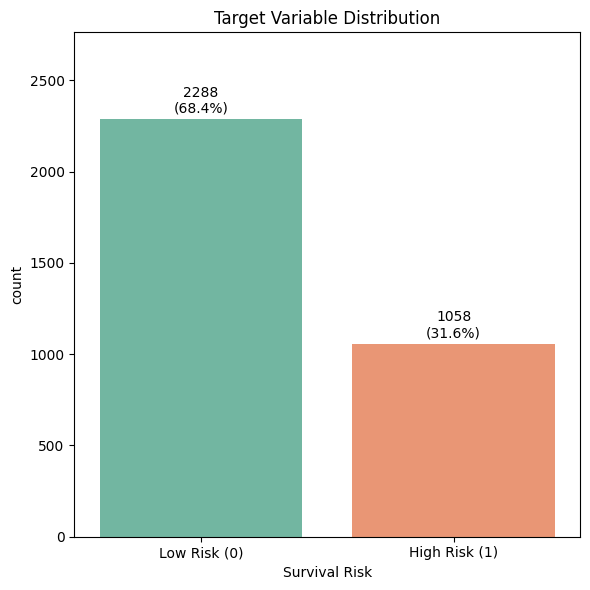

In [9]:
#Target Distribution Plot
fig, ax = plt.subplots(figsize=(6,6))
sns.countplot(data=df, x='status', palette="Set2", ax=ax)
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total

    ax.text(
        p.get_x() + p.get_width()/2,
        count + total*0.01,
        f"{count}\n({percent:.1f}%)",
        ha="center"
    )

ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Low Risk (0)", "High Risk (1)"])
ax.set_xlabel("Survival Risk")
ax.set_title("Target Variable Distribution")
plt.tight_layout()
plt.show()
print("\n\n\n")

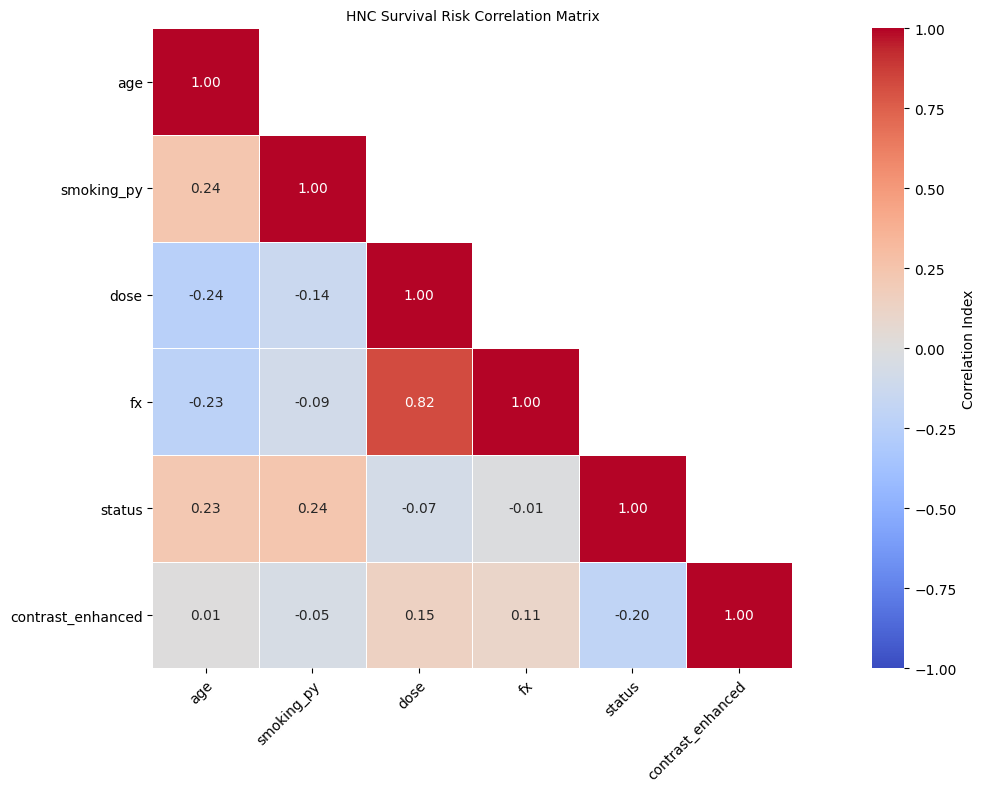

In [10]:
#Correlation Heatmap for Continuous Variables, EDA Toolkit Library (Shpaner & Gil, 2024)
df_num = df.select_dtypes(np.number)
flex_corr_matrix(
    df=df,
    cols=df_num.columns.to_list(),
    annot=True,
    cmap="coolwarm",
    figsize=(12, 8),
    title="HNC Survival Risk Correlation Matrix",
    xlabel_alignment="right",
    label_fontsize=10,
    tick_fontsize=10,
    xlabel_rot=45,
    ylabel_rot=0,
    text_wrap=50,
    vmin=-1,
    vmax=1,
    cbar_label="Correlation Index",
    triangular=True,
)
print("\n\n\n")

In [11]:
#Generate a variable, dose_per_fx
df["dose_per_fx"] = df["dose"] / df["fx"]

#Remove fx to prevent multicollinearity with dose per the correlation heatmap
df = df.drop(columns=["fx", "dose"])

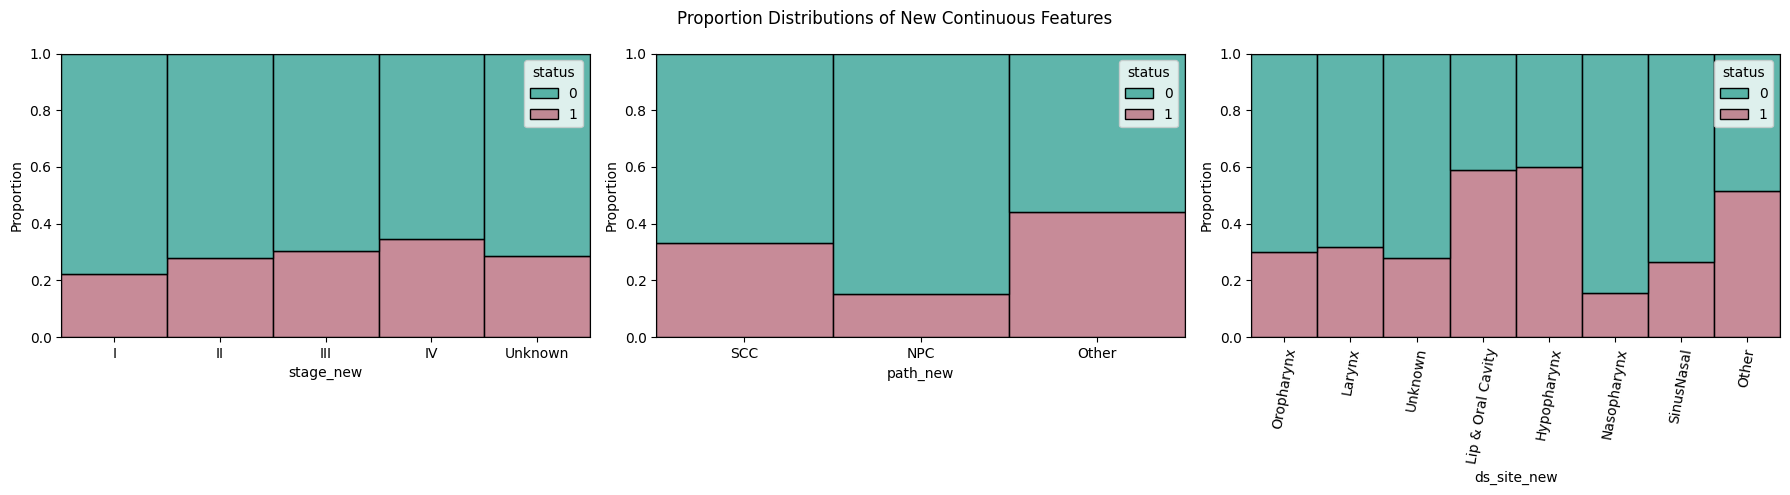

In [12]:
#stage_new feature ordering
df["stage_new"] = pd.Categorical(
    df["stage_new"],
    categories=["I", "II", "III", "IV", "Unknown"],
    ordered=True
)

palette = {
    0: "#2A9D8F",
    1: "#B56576"
}

#Proportion plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(
    data=df,
    x='stage_new',
    hue='status',
    stat='proportion',
    multiple='fill',
    palette=palette,
    ax=axes[0]
)

sns.histplot(
    data=df,
    x='path_new',
    hue='status',
    stat='proportion',
    multiple='fill',
    palette=palette,
    ax=axes[1]
)

sns.histplot(
    data=df,
    x='ds_site_new',
    hue='status',
    stat='proportion',
    multiple='fill',
    palette=palette,
    ax=axes[2]
)

fig.suptitle("Proportion Distributions of New Continuous Features")
plt.tick_params(axis='x', rotation=80)

plt.tight_layout()
plt.show()

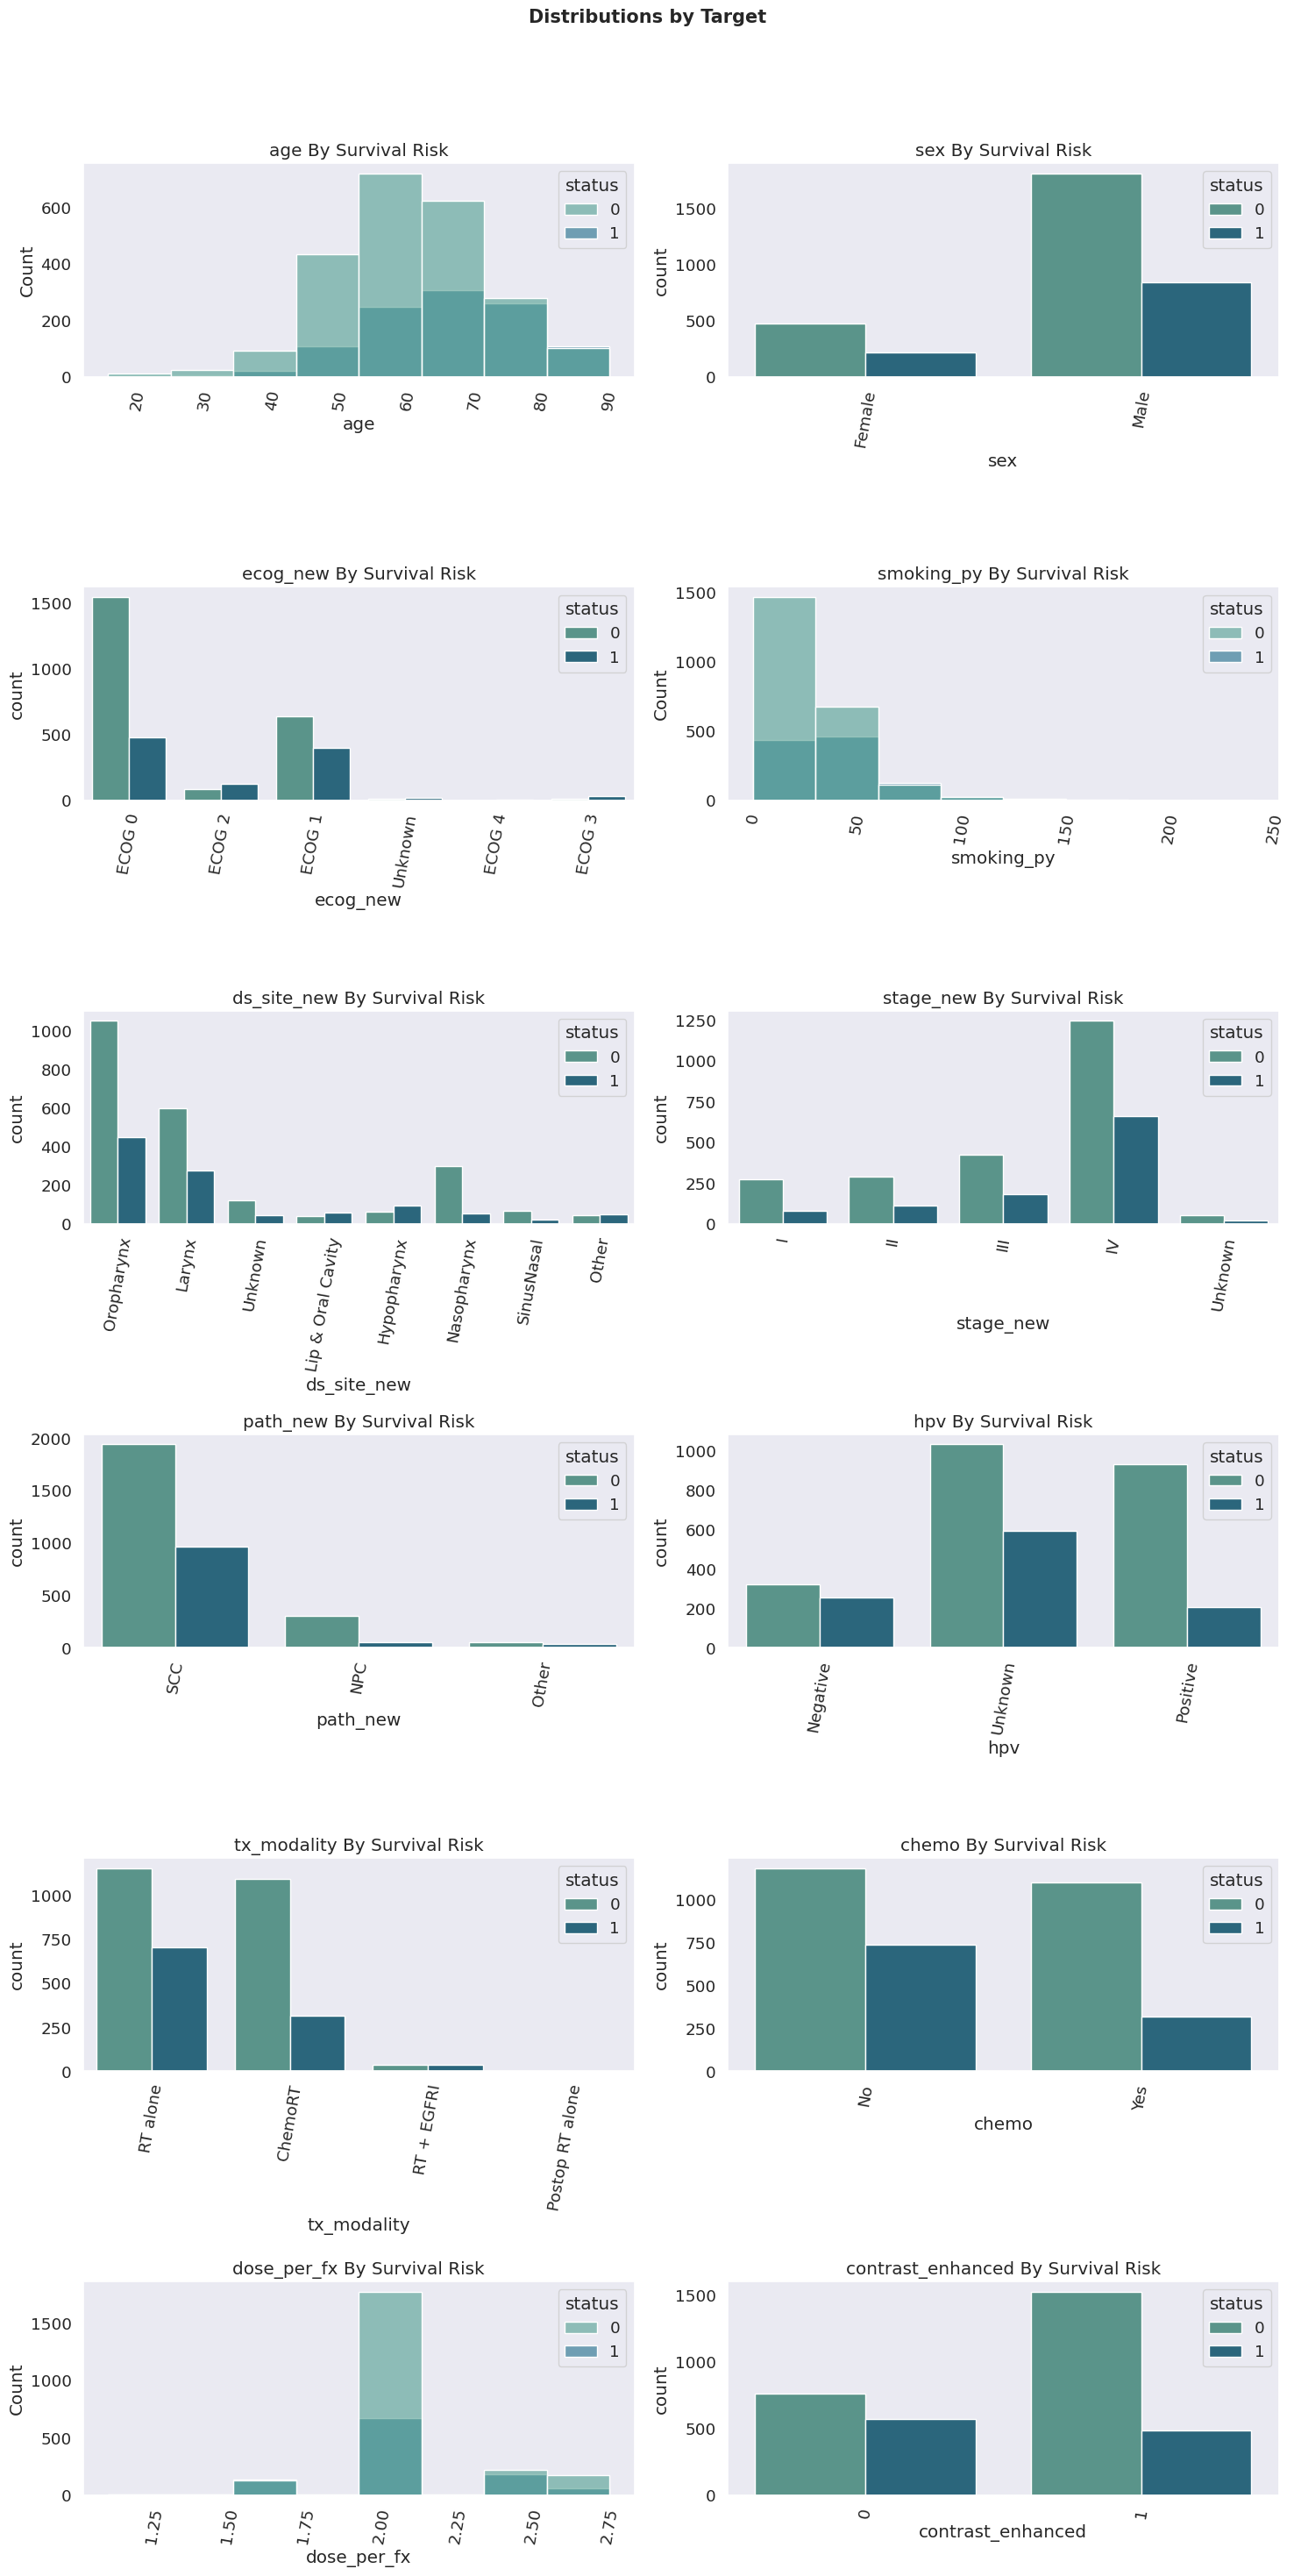

In [13]:
#Distribution Plots by Risk Class - Histogram and Count Plots
def features_by_target(df, column_plot, num_cols, w, h, title, target):

  data = df.copy()
  sns.set(font_scale=1.2, style="dark")
  custom_palette = {0: 'skyblue', 1: 'navy'}

  #Split the key and values
  keys_list = list(column_plot.keys())
  values_list = list(column_plot.values())

  #Set the rows and columns of the figure and grid
  n_plots = len(column_plot)
  n_cols = num_cols
  n_rows = int(math.ceil(n_plots/n_cols))

  gs = gridspec.GridSpec(n_rows, n_cols)
  fig = plt.figure(figsize=(w,h))

  #Create the related plot defined in the dictionary
  for i in range(n_plots):
   ax = fig.add_subplot(gs[i])
   if values_list[i] == 'hist':
     sns.histplot(data=data, x=keys_list[i], hue=target,
                  palette="crest", bins=8, alpha=0.6, ax=ax)
   elif values_list[i] == 'count':
      sns.countplot(data=data, x=keys_list[i], hue=target,
                    palette="crest", ax=ax)
   elif values_list[i] == 'box':
     sns.boxplot(data=data, x=keys_list[i], hue=target,
                 palette="crest", ax=ax, gap=0.2);
   else:
     print('Incorrect plot type, please check if column_plot has hist,' +
           'count or box plots only.')
   #Labels and title
   ax.set_xlabel(keys_list[i])
   ax.set_title(f"{keys_list[i]} By Survival Risk", loc='center')
   ax.tick_params(axis='x', rotation=80)
  fig.suptitle(title, fontsize=15, fontweight="bold", y=0.98, ha='center')
  plt.tight_layout(rect=[0, 0, 1, 0.95])

#Print Count and Histogram Plots
column_plot = {'age':'hist','sex':'count','ecog_new':'count', 'smoking_py':'hist','ds_site_new': 'count',
               'stage_new':'count', 'path_new':'count','hpv':'count','tx_modality':'count'
               ,'chemo':'count','dose_per_fx':'hist','contrast_enhanced':'count'}
features_by_target(df, column_plot, 2, 15, 30, 'Distributions by Target', 'status')
plt.show()
print("\n\n\n")

In [14]:
#Log Tranformation on heaviliy skewed smoking_py
df["smoking_py_log"] = np.log1p(df["smoking_py"])

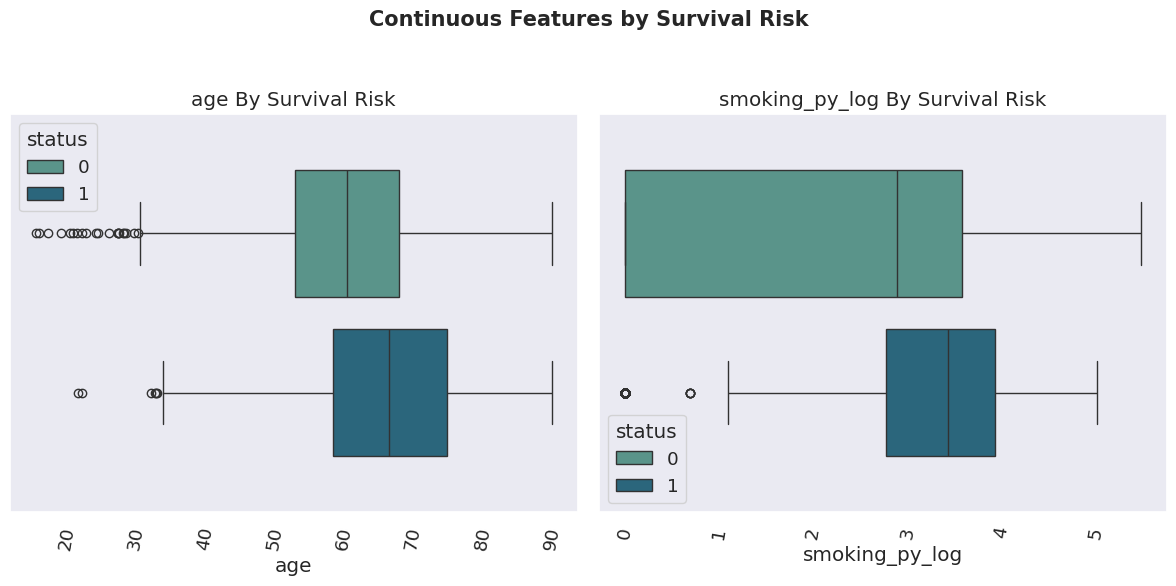

In [15]:
#Print Box Plots
column_plot = {'age':'box','smoking_py_log':'box'}
features_by_target(df, column_plot, 2, 12, 6, 'Continuous Features by Survival Risk', 'status')
print("\n\n\n")

In [16]:
#Make stage and ecog ordinal
stage_ord_map = {"I":1, "II":2, "III":3, "IV":4, "Unknown":0}
df["stage_ord"] = df["stage_new"].map(stage_ord_map)

ecog_map = {"ECOG 0":0, "ECOG 1":1, "ECOG 2":2, "ECOG 3":3, "ECOG 4":4, "Unknown":-1}
df["ecog_ord"] = df["ecog_new"].map(ecog_map)

In [17]:
#T-testing for continuous variables
cont_cols = ["age","smoking_py","dose_per_fx"]

for col in cont_cols:
    survival = df[df["status"] == 0][col].dropna()
    no_survival = df[df["status"] == 1][col].dropna()

    t_stat, p_val = ttest_ind(survival, no_survival, equal_var=False)

    print(f"\nFeature: {col}")
    print(f"P-value: {p_val:.5f}")
    if p_val < 0.05:
        print("Reject the null hypothesis. There is a significant difference between the mortality groups.")
    else:
        print("Fail to reject the null hypothesis. There is no significant difference between the mortality groups.")


Feature: age
P-value: 0.00000
Reject the null hypothesis. There is a significant difference between the mortality groups.

Feature: smoking_py
P-value: 0.00000
Reject the null hypothesis. There is a significant difference between the mortality groups.

Feature: dose_per_fx
P-value: 0.30724
Fail to reject the null hypothesis. There is no significant difference between the mortality groups.


In [18]:
#Chi-square testing for categorical variables
cols = ["sex","ecog_new","ds_site_new", "stage_new", "path_new", "hpv","tx_modality","chemo","contrast_enhanced"]
for col in cols:
    table = pd.crosstab(df[col], df["status"])
    chi2, p_val, dof, expected = chi2_contingency(table)

    print(f"\nFeature: {col}")
    print(f"P-value: {p_val:.5f}")

    if p_val < 0.05:
        print("Reject the null hypothesis. There is a significant association with mortality.")
    else:
        print("Fail to reject the null hypothesis. No significant association with mortality.")


Feature: sex
P-value: 0.75335
Fail to reject the null hypothesis. No significant association with mortality.

Feature: ecog_new
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: ds_site_new
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: stage_new
P-value: 0.00005
Reject the null hypothesis. There is a significant association with mortality.

Feature: path_new
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: hpv
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: tx_modality
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: chemo
P-value: 0.00000
Reject the null hypothesis. There is a significant association with mortality.

Feature: contrast_enhanced
P-value: 0.00000
Reject the null hypothesis. There is a si

### Logistic Regression (LR) and Random Forest (RF) Algorithm Application w/o Treatment Variables

In [19]:
#2 copies of the dataset to be used in models
df_before_treatments = df.copy()
df_after_treatments = df.copy()

df_before_treatments = df_before_treatments.drop(columns=["smoking_py","tx_modality","chemo","dose_per_fx","contrast_enhanced", "stage_new", "ecog_new"])
df_after_treatments = df_after_treatments.drop(columns=["smoking_py","stage_new","ecog_new"])

### LR without Treatment Variables

In [20]:
#Train and test split of the first dataset (Before treatment variables)
#Make variables numeric
X_before = pd.get_dummies(df_before_treatments.drop(columns=["status"]), drop_first=True)
y_before = df_before_treatments["status"]

#80:20 split
X_train_before, X_test_before, y_train_before, y_test_before = train_test_split(X_before, y_before, test_size=0.2,
                                                    random_state=42, stratify=y_before)

#Apply SMOTE for the imbalance, a scaler and logistic regression to pipeline and fit the model
pipe_LR_1 = Pipeline([("smote", SMOTE(random_state=42)),("scaler", StandardScaler()),("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])
LR_after = pipe_LR_1.fit(X_train_before, y_train_before)

y_pred1 = pipe_LR_1.predict(X_test_before)
y_prob1 = pipe_LR_1.predict_proba(X_test_before)[:, 1]
report1 = classification_report(y_test_before, y_pred1)

print("\nAccuracy:", accuracy_score(y_test_before, y_pred1))
print("\nROC-AUC:", roc_auc_score(y_test_before, y_prob1))
print("\nClassification Report:\n", report1)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_before, y_pred1))


Accuracy: 0.6492537313432836

ROC-AUC: 0.6941120128532587

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.70      0.73       458
           1       0.45      0.54      0.49       212

    accuracy                           0.65       670
   macro avg       0.61      0.62      0.61       670
weighted avg       0.67      0.65      0.66       670


Confusion Matrix:
 [[320 138]
 [ 97 115]]


<Axes: >

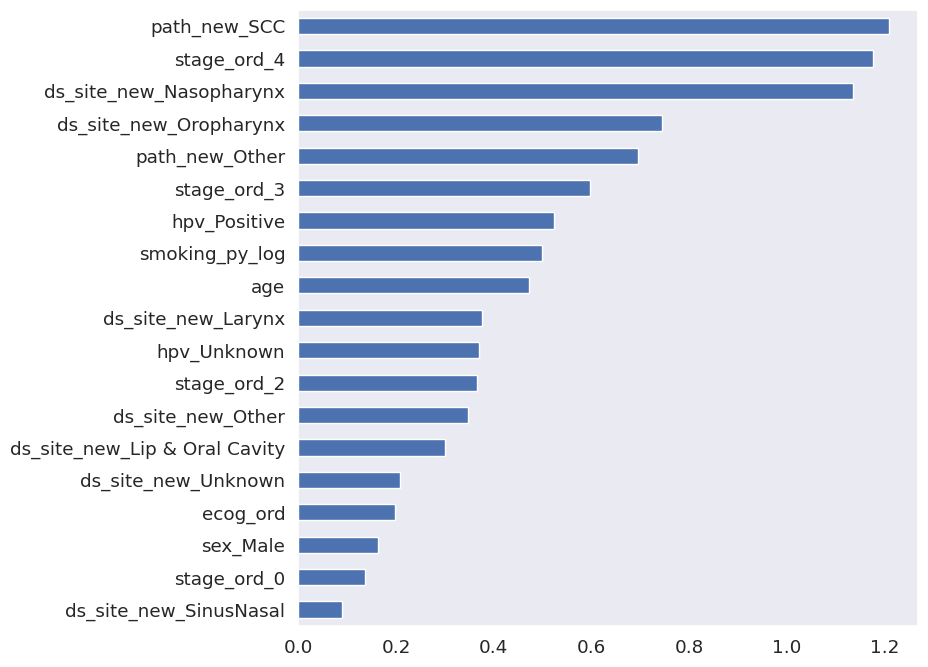

In [21]:
#Feature coefficients and plot to show feature importance
coefs = pd.Series(pipe_LR_1.named_steps["logreg"].coef_[0], index=X_before.columns)
plt.figure(figsize=(8, 8))
coefs.abs().sort_values().plot(kind='barh')

### RF without Treatment Variables

In [22]:
pipe_RF_1 = Pipeline([("smote", SMOTE(random_state=42)), ("rf", RandomForestClassifier(class_weight="balanced", random_state=42))])

parameters = {
        "rf__max_depth": [None, 10, 20, 30],
        "rf__n_estimators": [50, 100, 200, 500],
        "rf__min_samples_split": [2, 5, 10],
        "rf__min_samples_leaf": [1, 2, 4]
        }

grid_search = GridSearchCV(estimator=pipe_RF_1, param_grid=parameters, scoring="recall")
RF_before = grid_search.fit(X_train_before, y_train_before)

print(RF_before.best_params_)

y_pred2 = RF_before.predict(X_test_before)
y_prob2 = RF_before.predict_proba(X_test_before)[:, 1]
report2 = classification_report(y_test_before, y_pred2)

print("Accuracy:", accuracy_score(y_test_before, y_pred2))
print("\nROC-AUC:", roc_auc_score(y_test_before, y_prob2))
print("\nClassification Report:\n", report2)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_before, y_pred2))

{'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Accuracy: 0.6776119402985075

ROC-AUC: 0.710487558704787

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.71      0.75       458
           1       0.49      0.60      0.54       212

    accuracy                           0.68       670
   macro avg       0.64      0.66      0.65       670
weighted avg       0.70      0.68      0.69       670


Confusion Matrix:
 [[326 132]
 [ 84 128]]


<Axes: >

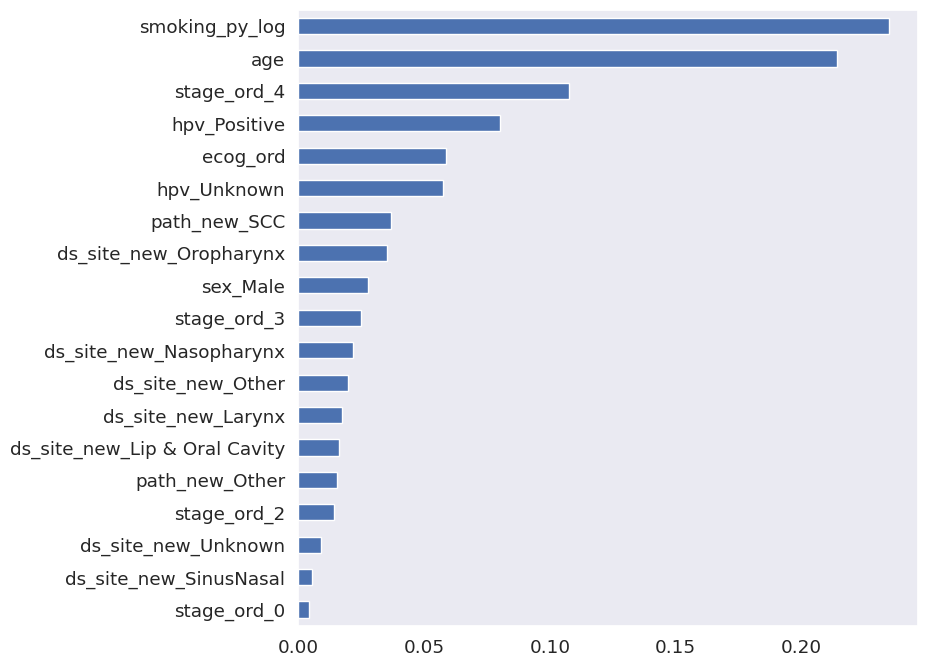

In [23]:
#Feature importance plot
rf_model1 = grid_search.best_estimator_.named_steps["rf"]
importances = pd.Series(rf_model1.feature_importances_, index=X_before.columns)
plt.figure(figsize=(8, 8))
importances.sort_values().plot(kind='barh')

### Logistic Regression and Random Forest Algorithm Application with Treatment Variables

### LR with Treatment Variables

In [24]:
#Train and test split of the first dataset (After treatment variables)
#Make variables numeric
X_after = pd.get_dummies(df_after_treatments.drop(columns=["status"]), drop_first=True)
y_after = df_after_treatments["status"]

#80:20 split
X_train_after, X_test_after, y_train_after, y_test_after = train_test_split(X_after, y_after, test_size=0.2,
                                                    random_state=42, stratify=y_after)

#Apply SMOTE for the imbalance, a scaler and logistic regression to pipeline and fit the model
pipe_LR_2 = Pipeline([("smote", SMOTE(random_state=42)),("scaler", StandardScaler()),("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))])
LR_after = pipe_LR_2.fit(X_train_after, y_train_after)

y_pred3 = pipe_LR_2.predict(X_test_after)
y_prob3 = pipe_LR_2.predict_proba(X_test_after)[:, 1]
report3 = classification_report(y_test_after, y_pred3)

print("\nAccuracy:", accuracy_score(y_test_after, y_pred3))
print("\nROC-AUC:", roc_auc_score(y_test_after, y_prob3))
print("\nClassification Report:\n", report3)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_after, y_pred3))


Accuracy: 0.7029850746268657

ROC-AUC: 0.7454169069786603

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.75      0.78       458
           1       0.53      0.60      0.56       212

    accuracy                           0.70       670
   macro avg       0.67      0.68      0.67       670
weighted avg       0.72      0.70      0.71       670


Confusion Matrix:
 [[343 115]
 [ 84 128]]


<Axes: >

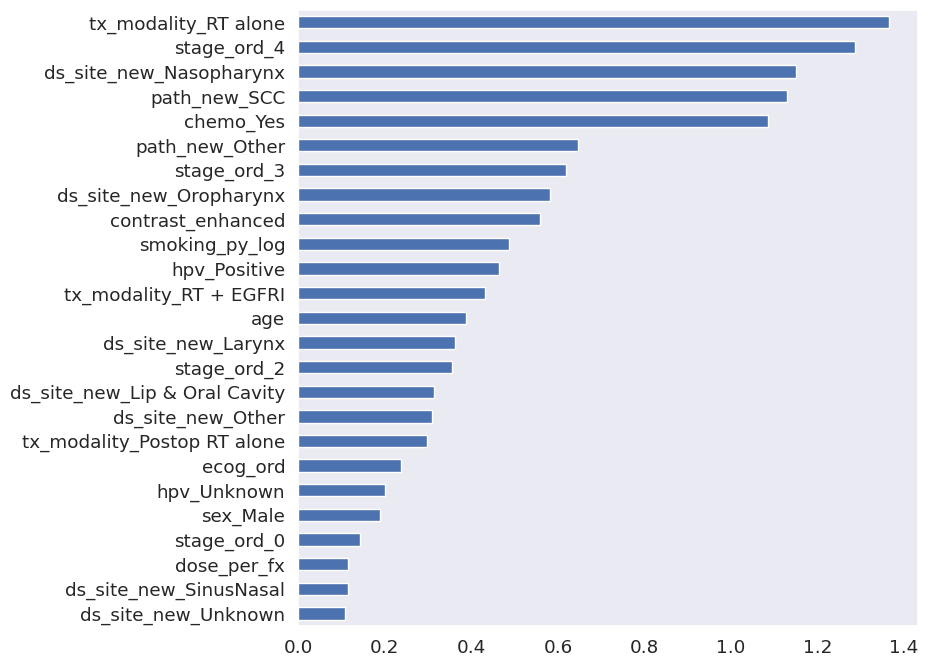

In [25]:
#Feature coefficients and plot to show feature importance
coefs2 = pd.Series(pipe_LR_2.named_steps["logreg"].coef_[0], index=X_after.columns)
plt.figure(figsize=(8, 8))
coefs2.abs().sort_values().plot(kind='barh')

### RF with Treatment Variables

In [26]:
pipe_RF_2 = Pipeline([("smote", SMOTE(random_state=42)), ("rf", RandomForestClassifier(class_weight="balanced", random_state=42))])

grid_search2 = GridSearchCV(estimator=pipe_RF_2, param_grid=parameters, scoring="recall") #same parameters
RF_after = grid_search2.fit(X_train_after, y_train_after)

print(RF_after.best_params_)

y_pred4 = RF_after.predict(X_test_after)
y_prob4 = RF_after.predict_proba(X_test_after)[:, 1]
report4 = classification_report(y_test_after, y_pred4)

print("Accuracy:", accuracy_score(y_test_after, y_pred4))
print("\nROC-AUC:", roc_auc_score(y_test_after, y_prob4))
print("\nClassification Report:\n", report4)
print("\nConfusion Matrix:\n", confusion_matrix(y_test_after, y_pred4))

{'rf__max_depth': 10, 'rf__min_samples_leaf': 4, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Accuracy: 0.7089552238805971

ROC-AUC: 0.7543616626843537

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.73      0.77       458
           1       0.53      0.66      0.59       212

    accuracy                           0.71       670
   macro avg       0.68      0.70      0.68       670
weighted avg       0.73      0.71      0.72       670


Confusion Matrix:
 [[335 123]
 [ 72 140]]


<Axes: >

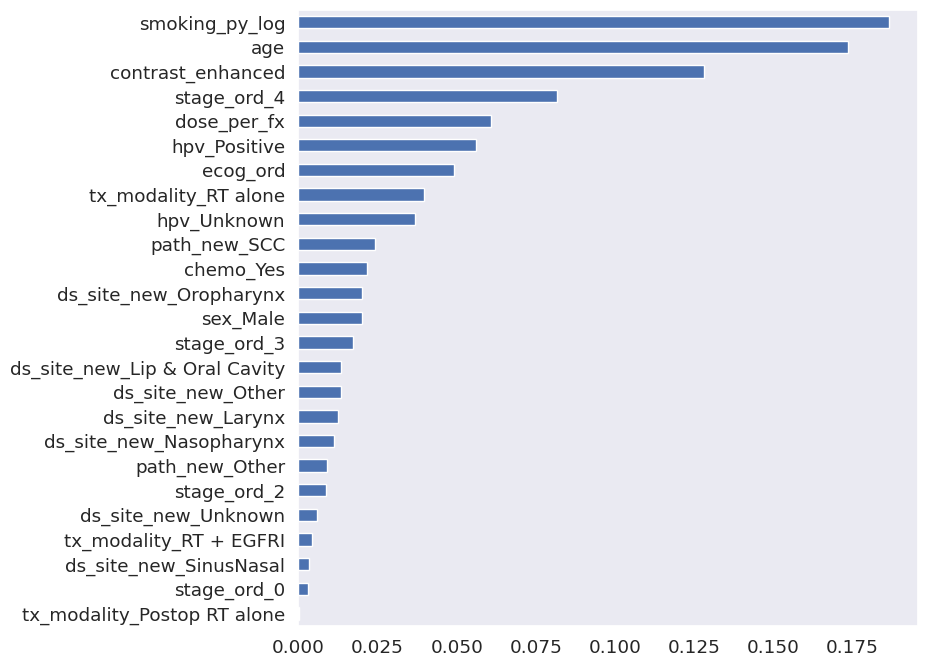

In [27]:
#Feature importance plot
rf_model2 = grid_search2.best_estimator_.named_steps["rf"]
importances = pd.Series(rf_model2.feature_importances_, index=X_after.columns)
plt.figure(figsize=(8, 8))
importances.sort_values().plot(kind='barh')

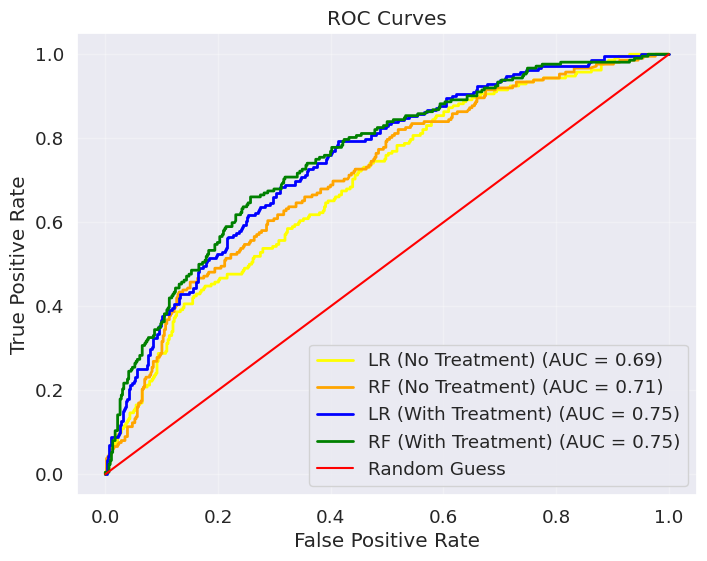

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

models = [
    ("LR (No Treatment)", pipe_LR_1, X_test_before, y_test_before, "yellow", "-"),
    ("RF (No Treatment)", grid_search, X_test_before, y_test_before, "orange", "-"),
    ("LR (With Treatment)", pipe_LR_2, X_test_after, y_test_after, "blue", "-"),
    ("RF (With Treatment)", grid_search2, X_test_after, y_test_after, "green", "-"),
]

for name, model, X, y, color, linestyle in models:
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr, tpr,
        label=f"{name} (AUC = {roc_auc:.2f})",
        color=color,
        linestyle=linestyle,
        linewidth=2
    )

#Random guess line
plt.plot([0, 1], [0, 1], color="red", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()